In [ ]:
# !sudo apt install graphviz libgraphviz-dev graphviz-dev pkg-config
!pip install pandas==1.1.5
!pip install tables==3.5.1
# !pip install pygraphviz
!pip install pydot
!pip install pydotplus
# !pip install pyparsing==1.5.7
!pip install -U javabridge
# !pip install git+git://github.com/bd2kccd/py-causal
# !pip install ananke-causal

In [1]:
import pandas as pd
import numpy as np
import pygraphviz
import pydot
import pydotplus
import pyparsing
import javabridge
import joblib
import torch
import tqdm
import pycausal
from pycausal import search as s
from pycausal.pycausal import pycausal as pc
import ananke
from ananke.graphs import ADMG
from ananke.estimation import CausalEffect
from IPython.display import SVG
# from google.colab import auth

/home/ian/anaconda3/envs/dis/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.__version__

'1.5.3'

In [ ]:
auth.authenticate_user()
#For the hypothesized causal features:
!gsutil -m cp -r gs://wps_pillar1a/data_working/phase_2/datacube_objects/datacube_disaggregated-admin2_flat.h5 .

#For the dimensionality-reduced features:
#!gsutil -m cp -r gs://wps_pillar1a/data_working/phase_2/datacube_objects/dimensionality_reduced_slice_TSNE_boosted_complete_robust_scaler_50_copy_2_flat.h5 .

Copying gs://wps_pillar1a/data_working/phase_2/datacube_objects/datacube_disaggregated-admin2_flat.h5...
| [1/1 files][  1.3 GiB/  1.3 GiB] 100% Done  44.4 MiB/s ETA 00:00:00           
Operation completed over 1 objects/1.3 GiB.                                      


In [3]:
df = pd.read_hdf('datacube_disaggregated-admin2_flat.h5', key = 'table')
df = df[['et_anom_m_STD_m', 'chicken_number_s', 'pig_number_s', 'Cropland2000_mean_percent_s', 'loccount_y', 'locdensity_y', 'rurpop_s',
                         'acl_viol_fatl_m', 'acl_batt_fatl_m', 'acl_batt_evnt_m', 'acl_viol_evnt_m', 'acl_sum_evnt_m', 'acl_sum_fatl_m']]

md = '2020-09-01'
thresholds = np.array([0.25, 0.75])

df = df.loc[df.index.get_level_values(level = 'month_date') == md]
df = df.droplevel(['month_date'])
df['rank_pct'] = df['et_anom_m_STD_m'].rank(pct=True)
df['treatment_et_anom'] = np.digitize(df.rank_pct, thresholds, right=True)
df = df[df.treatment_et_anom != 1]
df['treatment_et_anom'] = np.where(df['treatment_et_anom'] == 2, 1, 0)
df['treatment_et_anom'] = df['treatment_et_anom'].astype(int)
df = df.rename(columns={'acl_sum_evnt_m':'outcome'})
df = df.drop(['rank_pct', 'et_anom_m_STD_m'], axis=1)
df = df.dropna()
df = df.reset_index()
df = df.drop(columns = 'GID_2')

FileNotFoundError: File datacube_disaggregated-admin2_flat.h5 does not exist

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   chicken_number_s             268 non-null    float64
 1   pig_number_s                 268 non-null    float64
 2   Cropland2000_mean_percent_s  268 non-null    float64
 3   loccount_y                   268 non-null    float64
 4   locdensity_y                 268 non-null    float64
 5   rurpop_s                     268 non-null    float64
 6   acl_viol_fatl_m              268 non-null    float64
 7   acl_batt_fatl_m              268 non-null    float64
 8   acl_batt_evnt_m              268 non-null    float64
 9   acl_viol_evnt_m              268 non-null    float64
 10  outcome                      268 non-null    float64
 11  acl_sum_fatl_m               268 non-null    float64
 12  treatment_et_anom            268 non-null    int64  
dtypes: float64(12), int6

**TETRAD - CAUSAL DISCOVERY**

In [ ]:
pc = pc() #Initialization

faithfulnessAssumed: This is a parameter for FGES (“Fast GES”). If this is set to ‘Yes’, it will be assumed that if X _||_ Y, by an independence test, then X _||_ Y | Z for nonempty Z. If the model is faithful to the data, this will necessarily be the case. However, there are some non-faithful examples one can propose where this is not the case. If one is worried about this kind of unfaithfulness, one should set this parameter to ‘No’. If one is willing to tolerate this kind of unfaithfulness, then setting this parameter to ‘Yes’ leads to significantly faster searches. (java.lang.Boolean) [default:true]
maxDegree: It is possible for a random graph to have a single node with very high degree—i.e. number of adjacent edges. This parameter places an upper bound on the maximum such degree. If no limit is to be placed on the maximum degree, use the value -1. (java.lang.Integer) [default:100]
maxPathLength: See Spirtes, Glymour, and Scheines (2000), Causation, Prediction, and Search for the d

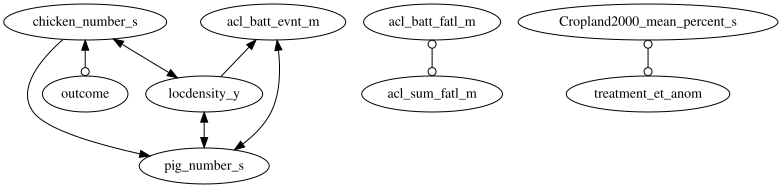

In [ ]:
pc.start_vm(java_max_heap_size = '6g') #Starting a Java virtual machine

tetrad = s.tetradrunner()

tetrad.getAlgorithmParameters(algoId = 'gfci', testId = 'cg-lr-test', scoreId = 'cg-bic-score')
tetrad.run(algoId = 'gfci', dfs = df2, testId = 'cg-lr-test', scoreId = 'cg-bic-score', dataType = 'mixed',
           numCategoriesToDiscretize = 20, maxDegree = 20, maxPathLength = 10,
           completeRuleSetUsed = True, faithfulnessAssumed = False)

graph = tetrad.getTetradGraph()
nodes = tetrad.getNodes()
edges = tetrad.getEdges()

dot_str = pc.tetradGraphToDot(graph)
graphs = pydot.graph_from_dot_data(dot_str)
svg_str = graphs[0].create_svg()
SVG(svg_str)

In [ ]:
#Below is the brute force approach to choosing the simplest admg from the Markov equivalence class that corresponds to the above partial ancestral graph.
#The brute force approach consists of two steps:
#First, we get the directed edges from the partial ancestral graph.

di_edges = tetrad.getEdges()
condition_dir = [" --> ", " o-> "]
di_edges[:] = [str for str in di_edges if any(sub in str for sub in condition_dir)]
di_edges = [str.replace(" --> ", "', '") for str in di_edges]
di_edges = [str.replace(" o-> ", "', '") for str in di_edges]
di_edges = [str.replace(str, "('" + str + "')") for str in di_edges]
di_edges = [eval(str) for str in di_edges]
di_edges

[('acl_viol_evnt_m', 'outcome'),
 ('Cropland2000_mean_percent_s', 'chicken_number_s'),
 ('treatment_et_anom', 'acl_batt_evnt_m'),
 ('treatment_et_anom', 'pig_number_s'),
 ('treatment_et_anom', 'Cropland2000_mean_percent_s'),
 ('acl_batt_evnt_m', 'outcome'),
 ('acl_viol_evnt_m', 'acl_batt_fatl_m'),
 ('treatment_et_anom', 'rurpop_s'),
 ('acl_sum_fatl_m', 'acl_batt_evnt_m'),
 ('treatment_et_anom', 'acl_batt_fatl_m'),
 ('treatment_et_anom', 'outcome'),
 ('acl_sum_fatl_m', 'acl_batt_fatl_m'),
 ('rurpop_s', 'Cropland2000_mean_percent_s')]

In [ ]:
#Second, we get the bidirected edges from the above partial ancestral graph.
#The Tetrad algorithm must be rerun for the following code to store both <-> and o-o as bidirected edges.

bi_edges = tetrad.getEdges()
condition_bi = [" <-> ", " o-o "]
bi_edges[:] = [str for str in bi_edges if any(sub in str for sub in condition_bi)]
bi_edges = [str.replace(" <-> ", "', '") for str in bi_edges]
bi_edges = [str.replace(" o-o ", "', '") for str in bi_edges]
bi_edges = [str.replace(str, "('" + str + "')") for str in bi_edges]
bi_edges = [eval(str) for str in bi_edges]
bi_edges

#The brute force approach should be replaced by a PAG2ADMG-like algorithm that extracts the entire Markov equivalence class from the above partial ancestral graph,
#followed by a heuristic choice of the element from this class.

#A simple heuristic can be:
#a) "If there is a path between treatment and outcome, choose the easiest admg from the Markov equivalence class, the one that has the greatest number of
#directed edges between the treatment and outcome! If identification and estimation are not possible, choose the second easiest element.
#Proceed until the identification and estimation are possible!"
#or
#b) "If there is a path between treatment and outcome, choose the hardest admg from the Markov equivalence class, the one that has the smallest number of
#directed edges between the treatment and outcome. If identification and estimation are not possible, choose the second hardest element.
#Proceed until the identification and estimation are possible!"

[('chicken_number_s', 'pig_number_s'),
 ('loccount_y', 'rurpop_s'),
 ('chicken_number_s', 'treatment_et_anom'),
 ('acl_viol_evnt_m', 'acl_viol_fatl_m'),
 ('Cropland2000_mean_percent_s', 'pig_number_s'),
 ('Cropland2000_mean_percent_s', 'locdensity_y'),
 ('loccount_y', 'locdensity_y'),
 ('loccount_y', 'treatment_et_anom')]

In [ ]:
#pc.stop_vm() #Stopping the Java virtual machine

**ANANKE - CAUSAL IDENTIFICATION AND ESTIMATION**

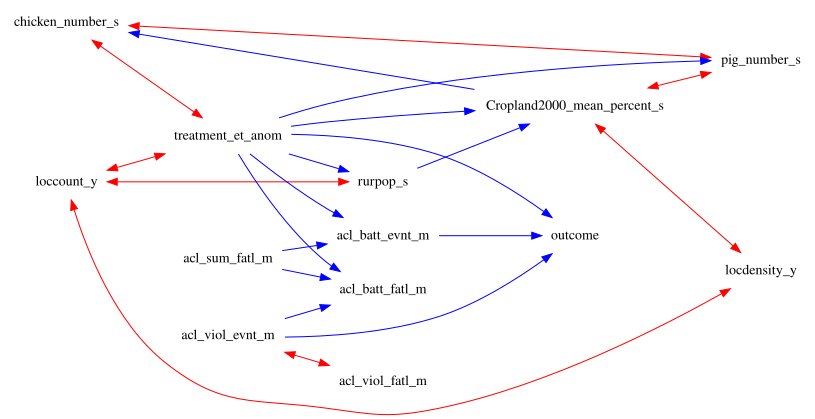

In [ ]:
admg = ADMG(nodes, di_edges = di_edges, bi_edges = bi_edges)
admg.draw(direction="LR")

In [ ]:
ace_obj = CausalEffect(graph= admg, treatment='treatment_et_anom', outcome='outcome')


 Effect is identified. 
 
 Available estimators:
 
1. Nested IPW (n-ipw)
2. Augmented NIPW (anipw) 

Suggested estimator is Augmented NIPW 



In [ ]:
ace, ql, qu = ace_obj.compute_effect(df, "n-ipw", n_bootstraps = 100, alpha=0.05)
print("average causal effect = ", ace)

#We have to check standard error for standardized coefficient as well as the distribution of choice, but since we bootstrapped our estimates,
#the following is generally okay as an initial approximation of the standard error:
print("standard error = ", (qu-ql)/3.92)
#In case of the standard normal distribution, 3.92 is 2 * z value for the applied 95% confidence interval: 2 * 1.96 = 3.92. The 2 comes from the fact that we're using the 95% two-sided confidence interval.

average causal effect =  0.06415067606497601
standard error =  0.027507203539022834


In [ ]:
ace, ql, qu = ace_obj.compute_effect(df, "anipw", n_bootstraps = 100, alpha=0.05)
print("average causal effect = ", ace)

#We have to check standard error for standardized coefficient as well as the distribution of choice, but since we bootstrapped our estimates,
#the following is generally okay as an initial approximation of the standard error:
print("standard error = ", (qu-ql)/3.92)
#In case of the standard normal distribution, 3.92 is 2 * z value for the applied 95% confidence interval: 2 * 1.96 = 3.92. The 2 comes from the fact that we're using the 95% two-sided confidence interval.

average causal effect =  0.06415067606492034
standard error =  0.02924752436737357


In [ ]:
#Obviously, the probability distribution has to be chosen appropriately. In case of count data, the common choices are the Poisson distribution or the negative binomial distribution).
#Moreover, the coefficients should be standardized, and then standard errors must be calculated for standardized coefficients.
#Finally, all of this should be automated. Ananke enables construction of custom estimators based on the identifying functionals/nonparametric influence functions.
#Hence, one can deploy one's own estimation strategies, by possibly resorting to Python packages such as statsmodels or EconML.